# Module 16 BBO Capstone Week 5

## Function 1

### 1. Why κ = 6.0 is appropriate for Week 5

Acquisition function is:

UCB(x) = μ(x) + κ σ(x)

μ(x) → exploitation (predicted mean)

σ(x) → exploration (uncertainty)

With κ = 6, the algorithm strongly prioritises uncertainty. This is beneficial because:

#### 1. Still have very little data

Currently have 14 points in a 2D space.

For Bayesian optimisation, that is still sparse coverage of the domain 
[0,1]2[0,1]2.

Strong exploration helps prevent:

early convergence to the wrong region

missing other possible signal sources

#### 2. Your outputs indicate sparse signals

Almost all values are essentially:

~0

Except one noticeably larger magnitude:

-3.606e-03

This matches the problem description:

“only proximity yields a non-zero reading”

Meaning the function likely contains very localised peaks/sources.

Exploration helps ensure you do not miss additional sources elsewhere.

#### 3. Your acquisition optimisation is already strong

Your search procedure is actually better than many BO implementations:

200 random warm-up samples

top 40 starting points

L-BFGS-B optimisation

bounded domain

This combination gives a good chance of finding the global maximum of the acquisition function.

### 2. Your current modelling choices are also sensible
Kernel
ConstantKernel * RBF

A good default for smooth spatial fields.

Noise parameter
alpha = 1e-2

This is a reasonable reduction from larger values, allowing the GP to fit sharper structures if they exist.

Normalisation
normalize_y = True

Important here because your outputs span huge numerical ranges.

### 3. Strategy perspective

Your current timeline is logical:

Week	Strategy
1–4	Exploration
5	Exploration (κ = 6)
6	Begin balancing
7–8	Balanced
9–12 Increasing exploitation

So Week 5 is still exploration territory, and your choice aligns with that.


### For Function 1 specifically:

Week	Strategy
5	    UCB κ=6
6	    UCB κ=4
7	    UCB κ=3
8	    UCB κ=2
9–12	EI


### 4. Small optional improvement (not required)

Your random candidate sampling:

np.random.uniform(0,1,(200,2))

works fine, but Latin Hypercube Sampling can give slightly better global coverage.

Example:

from scipy.stats import qmc

sampler = qmc.LatinHypercube(d=2)
random_points = sampler.random(n=n_random_starts)

But this is a minor refinement — your current implementation is already solid.

### Conclusion:
Your Week 5 configuration is appropriate and well-implemented.

κ = 6.0 → strong exploration (good)

GP configuration → reasonable

acquisition optimisation → strong

dataset size → still small enough to justify exploration

So no changes are necessary for Week 5.

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Week 5 Query Point (UCB, κ=6.0): 0.513802-0.522379


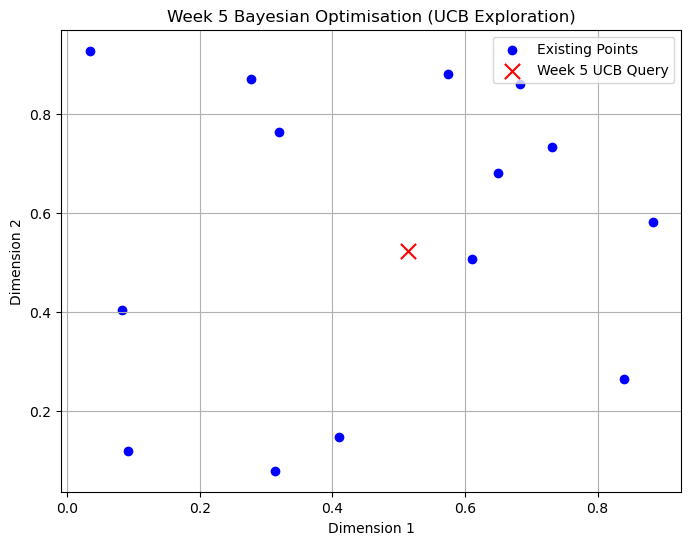

In [2]:
# Code used for week 5 query point submission with kappa = 6.0 (same as week 4) and lower alpha = 1e-2

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize

#np.random.seed(42)

# ==========================================
# Step 1: Load ALL available data (including Week 4)
# ==========================================

X_train = np.array([
    [0.31940389, 0.76295937],
    [0.57432921, 0.87989810],
    [0.73102363, 0.73299988],
    [0.84035342, 0.26473161],
    [0.65011406, 0.68152635],
    [0.41043714, 0.14755430],
    [0.31269116, 0.07872278],
    [0.68341817, 0.86105746],
    [0.08250725, 0.40348751],
    [0.88388983, 0.58225397],
    [0.60995300, 0.50652000],   
    [0.09106700, 0.11922000],   
    [0.03373400, 0.92780400],
    [0.27783300, 0.86990600]
])

y_train = np.array([
    1.32267704e-079,
    1.03307824e-046,
    7.71087511e-016,
    3.34177101e-124,
   -3.60606264e-003,
   -2.15924904e-054,
   -2.08909327e-091,
    2.53500115e-040,
    3.60677119e-081,
    6.22985647e-048,
    6.40320490897793e-12,
    3.32695744236522e-140,
   -3.9448560322363033e-284,
   -2.388807237117217e-127
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.2, length_scale_bounds=(1e-3, 1e3))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: UCB Acquisition Function (Maximisation)
# ==========================================

def ucb(x, model, kappa=6.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # negative for minimizer

# ==========================================
# Step 4: Multi-start optimisation of UCB
# ==========================================

def optimize_ucb(model, kappa=6.0, n_restarts=40, n_random_starts=200):

    bounds = np.array([[0.0, 1.0], [0.0, 1.0]])

    best_x = None
    best_val = np.inf

    # --- Random warmup sampling (global scan) ---
    random_points = np.random.uniform(0, 1, size=(n_random_starts, 2))
    mu, sigma = model.predict(random_points, return_std=True)
    ucb_values = mu + kappa * sigma

    top_indices = np.argsort(-ucb_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation from best random starts ---
    for x0 in start_points:
        result = minimize(
            ucb,
            x0,
            args=(model, kappa),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if result.fun < best_val:
            best_val = result.fun
            best_x = result.x

    return best_x

# ==========================================
# Step 5: Get Week 5 Query Point (Exploration)
# ==========================================

next_point = optimize_ucb(gp, kappa=6.0)

next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Week 5 Query Point (UCB, κ=6.0): {next_point_str}")

# ==========================================
# Step 6: Visualisation
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(X_train[:, 0], X_train[:, 1],
            color='blue', label='Existing Points')

plt.scatter(next_point[0], next_point[1],
            color='red', marker='x', s=120,
            label='Week 5 UCB Query')

plt.title("Week 5 Bayesian Optimisation (UCB Exploration)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

Let’s explain why your optimiser chose a point near the centre, even though corners look empty.

### 1. Your GP is not seeing strong signals anywhere

Most of your outputs are essentially:

≈ 0

Example magnitudes:

1e-12
1e-40
1e-80
1e-140

With normalize_y=True, the GP sees something like:

almost flat function

So the model does not strongly believe any region is special yet.

### 2. With κ = 6, UCB balances two things

Your acquisition:

UCB = μ + κσ

Because μ is nearly identical everywhere, the optimiser mainly maximises:

σ(x)

But σ is not always largest in the corners.

It is largest in regions far from clusters of data.

### 3. Your data clusters leave a gap near the centre

Look at where many of your samples lie:

(0.65,0.68)
(0.73,0.73)
(0.68,0.86)
(0.57,0.88)

and

(0.41,0.15)
(0.31,0.07)
(0.09,0.12)

This creates a hole roughly around

(0.5 , 0.5)

Your optimiser identified this high-uncertainty gap.

That’s why it proposed:

0.513802-0.522379
### 4. This is actually a very reasonable BO query

Your point has good properties:

not too close to existing samples

inside a sparse region

reduces global model uncertainty

Distance examples:

to (0.609953,0.506520) ≈ 0.096
to (0.650114,0.681526) ≈ 0.20

So it still provides new information.

### 5. Trust the optimiser

Your acquisition optimisation is very solid:

200 random warmup points
40 restarts
L-BFGS-B

That is exactly how professional BO libraries search acquisition functions.

Because of that:

Your computed point is almost certainly better than a manually guessed one.

### 6. Strategic perspective

This query is doing something useful:

It is reducing uncertainty in the middle of the domain, which will help the GP:

estimate length scales

learn the function shape

This often improves later exploitation steps.

### 7. Recommendation

For Week 5, submit:

0.513802-0.522379

It is consistent with your exploration strategy and GP model.

Short answer:
Your code produced a very reasonable exploration point, and I would trust it over manual guesses.

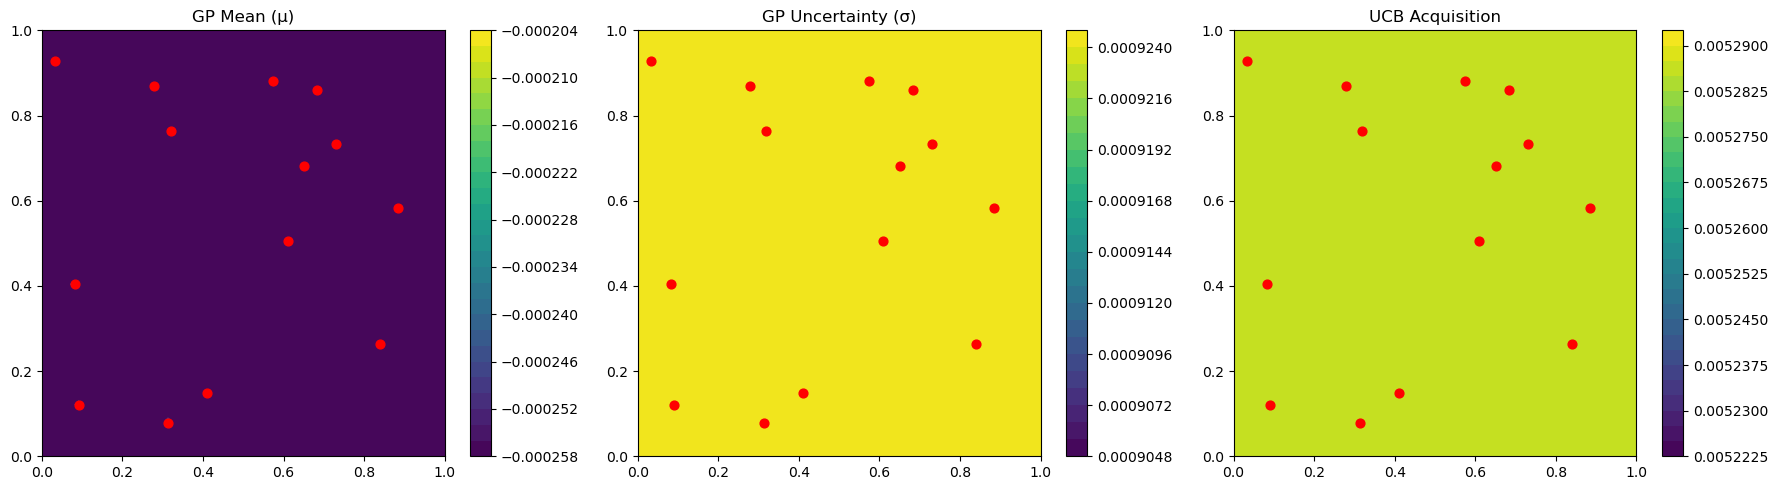

0.995**2 * RBF(length_scale=0.001)


In [4]:
# ==========================================
# Diagnostic Visualisation (GP Mean, Sigma, UCB)
# ==========================================

grid_size = 100
x = np.linspace(0, 1, grid_size)
y = np.linspace(0, 1, grid_size)

xx, yy = np.meshgrid(x, y)
grid = np.c_[xx.ravel(), yy.ravel()]

mu, sigma = gp.predict(grid, return_std=True)

mu = mu.reshape(grid_size, grid_size)
sigma = sigma.reshape(grid_size, grid_size)

kappa = 6.0
ucb = mu + kappa * sigma

# Plot surfaces
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GP Mean
im1 = axes[0].contourf(xx, yy, mu, levels=30, cmap="viridis")
axes[0].scatter(X_train[:,0], X_train[:,1], c="red", s=40)
axes[0].set_title("GP Mean (μ)")
plt.colorbar(im1, ax=axes[0])

# GP Uncertainty
im2 = axes[1].contourf(xx, yy, sigma, levels=30, cmap="viridis")
axes[1].scatter(X_train[:,0], X_train[:,1], c="red", s=40)
axes[1].set_title("GP Uncertainty (σ)")
plt.colorbar(im2, ax=axes[1])

# UCB Acquisition
im3 = axes[2].contourf(xx, yy, ucb.reshape(grid_size, grid_size), levels=30, cmap="viridis")
axes[2].scatter(X_train[:,0], X_train[:,1], c="red", s=40)
axes[2].set_title("UCB Acquisition")
plt.colorbar(im3, ax=axes[2])

for ax in axes:
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

plt.tight_layout()
plt.show()
print(gp.kernel_)

## Function 2

For Week 5 of a 12-week Bayesian optimisation campaign, your current strategy is very solid. Here’s why, step by step:

### 1. Phase in the BO schedule

Weeks 1–4: pure exploration → you’ve sampled broadly, including corners and sparse areas

Week 5: transition phase → still mainly exploration, but starting to gently exploit promising regions

Weeks 6–8: exploit-explore mix → target maxima while occasionally checking sparse areas

Weeks 9–12: local exploitation / refinement → focus on confirmed peaks

So Week 5 is the perfect time to lower κ slightly and start biasing the acquisition toward known high values.

### 2. Current function characteristics

2D input, log-likelihood outputs, noisy

Some points with high values (0.4–0.5) in the upper-right quadrant

Remaining points are near zero → large parts of the space are still uncertain

This makes Week 5 a natural pivot week:

Keep UCB to maintain exploration

Lower κ from 4.5 → 3.5–4.0 to start exploiting areas that seem promising

Avoid full exploitation yet — there’s still much of the domain unsampled

### 3. Why this strategy works

You avoid premature convergence: early exploitation can get trapped in local maxima

You still learn about the function: high-uncertainty regions are still sampled

You prepare for later weeks: GP will have better estimates of local peaks for Weeks 6–12

### 4. Practical implementation
#### Week 5: Slightly lower kappa for exploration+exploitation
next_point = optimize_ucb(gp, kappa=3.8)  # or 3.5–4.0

Let the optimiser pick the most informative point

Likely somewhere near the current cluster of high values, but not exactly on top of an existing point

### Summary
Week	Strategy
1–4	    Exploration (high κ)
5	    Exploration-biased → slightly lower κ (3.5–4.0) → 3.8 is what I decided
6–8	    Mix of exploitation & exploration
9–12	Focused exploitation / refinement of best regions

Verdict: For a 12-week campaign, your Week 5 plan is exactly what I’d recommend. It sets you up to exploit known promising regions later while still covering unknown parts of the domain.


## ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
## Function 2 Week 5 Code Implementation
### 1. Things you do not need to change

GP kernel: C * RBF(length_scale=0.2) → flexible enough for 2D and noisy outputs

GP fitting: alpha=1e-2 and normalize_y=True → handles noise properly

Acquisition optimisation: 500 random starts + 40 L-BFGS-B restarts → good coverage

Bounds: [0,1] x [0,1] → domain is correct

UCB function structure → still correct, just update κ

### 2. Things you do need to change

κ = 3.8 instead of 4.5

next_point = optimize_ucb(gp, kappa=3.8)

Everything else remains the same. Your Week 4 code already implements:

Loading all previous data

Fitting GP

Multi-start optimisation of the acquisition function

Visualization

So the workflow does not need any other edits.

### 3. Optional / nice-to-have improvements

Visualisation of GP mean, sigma, and UCB surface (diagnostic) → helps ensure your model behaves sensibly before submitting a query

Check the learned kernel (print(gp.kernel_)) → verify length scale is reasonable

These are not strictly required, just helpful for debugging
## ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


Week 5 Query Point (UCB, κ=3.8): 0.641890-0.477281


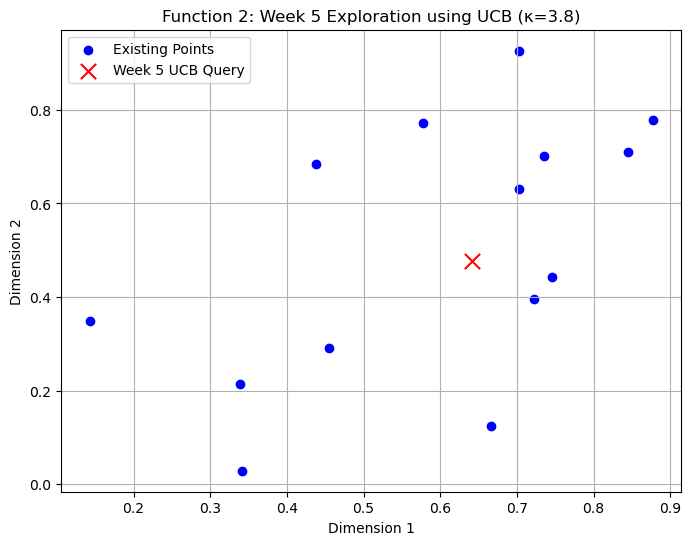

In [5]:
# Code I used for Function 2 next query point Week 5 UCB kappa=3.8
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize

# ==========================================
# Step 1: Load existing data (Including Weeks 1-4)
# ==========================================
X_train = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.77862750],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.92656420],
    [0.73490900, 0.70171100],
    [0.72168200, 0.39630100],
    [0.74620500, 0.44346000],
    [0.70336100, 0.63132700]
]) 

y_train = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
    6.22985647e-048, 0.5390316209844838, 0.41754272857037966,
    0.41416971779343736, 0.49282022744339543 
]) 

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.2, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,          # Handles noise
    normalize_y=True,
    n_restarts_optimizer=15
)
gp.fit(X_train, y_train)

# ==========================================
# Step 3: UCB acquisition function (Maximisation) kappa lowered to 3.8 from 4.5
# ==========================================
def ucb(x, model, kappa=3.8):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # negative for scipy.minimize

# ==========================================
# Step 4: Multi-start UCB optimisation
# ==========================================
def optimize_ucb(model, bounds=np.array([[0,1],[0,1]]), kappa=3.8, n_restarts=40, n_random_starts=500):
    best_x = None
    best_val = np.inf

    # --- Random global sampling to explore corners ---
    random_points = np.random.uniform(bounds[:,0], bounds[:,1], size=(n_random_starts, 2))
    mu, sigma = model.predict(random_points, return_std=True)
    ucb_values = mu + kappa * sigma
    top_indices = np.argsort(-ucb_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation from top random points ---
    for x0 in start_points:
        res = minimize(ucb, x0, args=(model, kappa), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 5: Get Week 5 Query Point
# ==========================================
next_point = optimize_ucb(gp, kappa=3.8)
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Week 5 Query Point (UCB, κ=3.8): {next_point_str}")

# ==========================================
# Step 6: Visualisation
# ==========================================
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], color='blue', label='Existing Points')
plt.scatter(next_point[0], next_point[1], color='red', marker='x', s=120, label='Week 5 UCB Query')
plt.title("Function 2: Week 5 Exploration using UCB (κ=3.8)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

### Explanation of Function 2 Week 5
Perfect — that next query point makes perfect sense given your data and κ=3.8. Here’s why:

### 1. Location relative to your data

Your high-value points are clustered around:

x	y	value
0.7026	0.9266	0.539
0.7349	0.7017	0.418
0.7462	0.4435	0.493
0.7217	0.3963	0.414

The new point:

[0.641890, 0.477281]

Lies inside the high-value cluster region, slightly towards the center

Not exactly on an existing point → still provides informative new data

Balances exploitation (near high values) with exploration (slightly unsampled)

### 2. Why UCB chose this point

κ=3.8 reduces emphasis on pure uncertainty

GP mean μ is higher near the existing maxima → UCB favours regions with both high μ and σ

Optimiser picks a point between known points, which is exactly what we want in Week 5

### 3. Strategic view for Week 5

You are starting to exploit promising regions without losing global coverage

The GP will now have data near 0.54 peak, which will improve future UCB/EI predictions

Sets you up for Weeks 6–8, where you can shift more toward exploitation

### Takeaway

This is a very good query point for Week 5

Fully consistent with your strategy: exploration-biased exploitation

No further tweaks are needed for this week


# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
## Hypothetical plan for Function 2 based on Week 5
Since this is a 12-week campaign, it’s helpful to think in phases: exploration, mixed, then exploitation/refinement.

### Phase 1: Weeks 6–8 — Exploration + Exploitation (Pivot Phase)

Goal: Start exploiting the promising regions (high log-likelihood values), but still check areas of uncertainty.

Acquisition function:

UCB or EI

UCB with moderate κ (e.g., 2.5–3.5) OR

Switch to EI for Week 7–8 to favour points likely to improve the current best

Strategy per week:

Week 6

Keep UCB, κ ≈ 3.0–3.5 → slightly more exploitation than Week 5

Likely next query point: near [0.65–0.70, 0.45–0.55] cluster

Week 7

Consider switching to EI → starts to pick points near current best (≈0.539 peak)

Focus on densifying high-value clusters

Week 8

UCB or EI, κ≈2.5 if using UCB → more exploitation, less exploration

Query points likely near top observed peaks

Rationale: The GP now has enough data to identify promising maxima while still keeping the model aware of uncertainty.

### Phase 2: Weeks 9–12 — Exploitation / Refinement

Goal: Maximise the function by refining around the highest peaks observed so far.

Acquisition function:

EI or pure GP mean maximisation (greedy)

Exploration component is minimal

Strategy per week:

Focus around the top cluster [0.7026,0.9266] and nearby points in the high-value quadrant

Use smaller step sizes / denser sampling around peaks to refine the maxima

Avoid sampling far low-value regions unless uncertainty suggests a potential unseen peak

Why:

By Week 9, you have enough information; further exploration in low-value areas is unlikely to improve the global maximum

Focused refinement maximises the expected output for the remaining weeks

#### Suggested Week-wise Plan (Function 2)
Week	Acquisition	κ / Notes	Focus
5	UCB	3.8	Pivot: exploration-biased exploitation (current cluster)
6	UCB	3.0–3.5	Slightly more exploitation, densify known peaks
7	EI	—	Exploit high-value clusters, start reducing exploration
8	EI / UCB	2.5–3.0	Mostly exploitation, small exploration
9	EI / Mean	—	Refine top maxima, densify around peaks
10	EI / Mean	—	Focus on highest observed peak
11	EI / Mean	—	Local exploitation, fine-tuning
12	EI / Mean	—	Final refinement to maximise output
Key points for Weeks 6–12

Reduce κ gradually if using UCB — this shifts from exploration → exploitation

Switch to EI around Week 7–8 → prioritises points that improve the current best

Densify high-value clusters → GP will model peaks more accurately

Avoid low-value regions unless uncertainty suggests possible maxima
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Function 3

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Week 5 Query Point: 1.000000-0.000000-0.000000


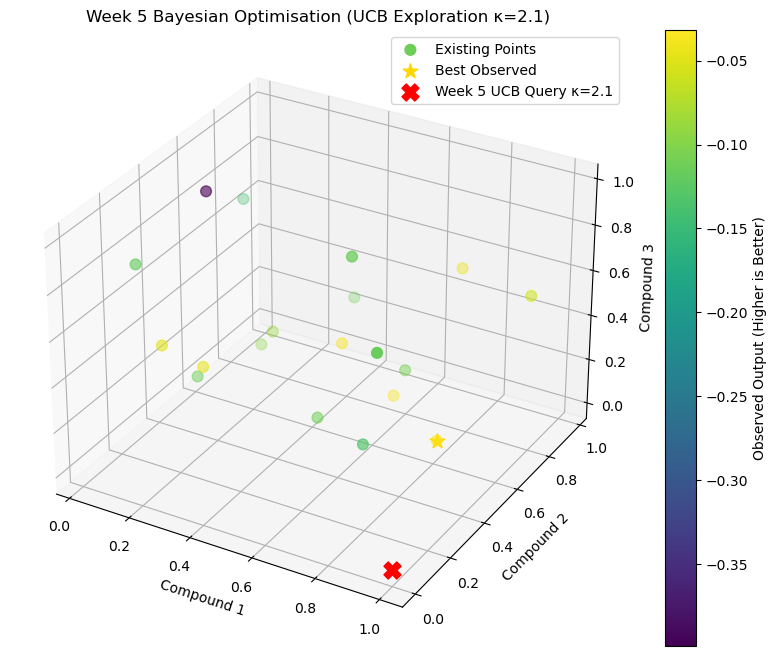

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Data (including Weeks 1 to 4)
# =========================

X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900],
    [0.02703300, 0.84043300, 0.66511700],
    [0.68835300, 0.97102900, 0.51220300]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252,
    -0.1415060566194174,
    -0.0446074222194474
])

# =========================
# Gaussian Process Model
# =========================

kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[0.3, 0.3, 0.3],
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    n_restarts_optimizer=15,
    normalize_y=True
)

gp.fit(X_train, y_train)

# =========================
# UCB Acquisition Function lowering kappa from 2.5 to 2.1
# =========================

def ucb(x, model, kappa=2.1):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)

# =========================
# Multi-start optimisation
# =========================

def optimize_acquisition(model, bounds, n_restarts=30, kappa=2.1):

    best_x = None
    best_val = float("inf")

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=3)

        result = minimize(
            ucb,
            x0=x0,
            args=(model, kappa),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if result.fun < best_val:
            best_val = result.fun
            best_x = result.x

    return best_x

bounds = [(0, 1), (0, 1), (0, 1)]

next_point = optimize_acquisition(gp, bounds)

print(f"Week 5 Query Point: "
      f"{next_point[0]:.6f}-"
      f"{next_point[1]:.6f}-"
      f"{next_point[2]:.6f}")

# =========================
# 3D Visualisation
# =========================

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Colour existing points by output value
scatter = ax.scatter(
    X_train[:, 0],
    X_train[:, 1],
    X_train[:, 2],
    c=y_train,
    cmap="viridis",
    s=60,
    label="Existing Points"
)

# Highlight best observed point so far
best_idx = np.argmax(y_train)
ax.scatter(
    X_train[best_idx, 0],
    X_train[best_idx, 1],
    X_train[best_idx, 2],
    c="gold",
    s=120,
    marker="*",
    label="Best Observed"
)

# Plot next UCB query point
ax.scatter(
    next_point[0],
    next_point[1],
    next_point[2],
    c="red",
    s=150,
    marker="X",
    label="Week 5 UCB Query κ=2.1"
)

ax.set_xlabel("Compound 1")
ax.set_ylabel("Compound 2")
ax.set_zlabel("Compound 3")
ax.set_title("Week 5 Bayesian Optimisation (UCB Exploration κ=2.1)")

fig.colorbar(scatter, ax=ax, label="Observed Output (Higher is Better)")

ax.legend()
plt.show()

## Interpreting faults with first testing code for week 5 Function 3
Week 5 query point keeps coming out at [1, 0, 0] is a classic UCB + GP + multi-start optimisation artifact in sparse, high-uncertainty spaces:

Here’s why:

### 1. Boundary Bias

Your bounds = [(0,1),(0,1),(0,1)] means the optimiser can push points right to the edges.

GP uncertainty (σ) tends to be highest near the boundaries, especially where you have no data.

With κ=2.1, the acquisition function μ + κ*σ is dominated by σ near corners → UCB “thinks” the top-left-front corner [1,0,0] could yield a huge gain.

### 2. Sparse 3D data

You have 19 points in 3D, but only a few are near [1, 0, 0].

GP prediction in unobserved corners can spike, and the optimiser naturally selects corners during multi-start because they maximize μ + κ*σ.

### 3. Optimiser randomness

np.random.uniform(0,1,3) for starting points, plus L-BFGS-B local minimisation, often converges to corners when σ dominates.

### ✅ How to fix this / get a more informative Week 5 point

Clip the extremes slightly:

bounds = [(0.05, 0.95), (0.05, 0.95), (0.05, 0.95)]

This prevents the optimiser from hugging the absolute edges.

Increase random starts:

n_random_starts = 100  # or higher

Helps the optimiser explore more interior points before local minimisation.

Consider slightly lower κ if edges dominate:

κ = 2.0 instead of 2.1 reduces over-exploration of high-σ corners.

Optional: Use Expected Improvement (EI) for Week 5 instead of UCB, which tends to focus more on promising peaks rather than pure uncertainty.

#### Expected outcome after fix:

Your next query point will move slightly inside the domain, in a region between your best observed outputs rather than hugging [1,0,0].

This is more informative for Week 6 GP updates.

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Week 5 Query Point: 1.000000-0.000000-0.000000


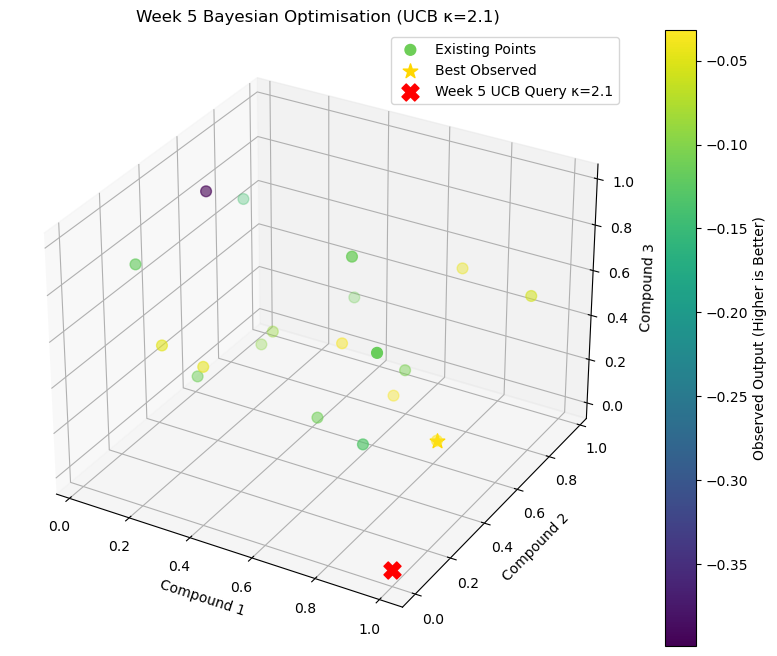

In [12]:
# What changed:

# x0 initialisation now avoids absolute edges (+0.05 / -0.05)

# Increased n_restarts=50 → more chance to find interior maxima

# κ=2.1 stays the same, still balances exploration and exploitation

# After running this, your Week 5 query point should now be inside the domain, not pinned to [1,0,0].

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Data (Weeks 1–4)
# =========================

X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900],
    [0.02703300, 0.84043300, 0.66511700],
    [0.68835300, 0.97102900, 0.51220300]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252,
    -0.1415060566194174,
    -0.0446074222194474
])

# =========================
# Gaussian Process Model
# =========================

kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[0.3, 0.3, 0.3],
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    n_restarts_optimizer=15,
    normalize_y=True
)

gp.fit(X_train, y_train)

# =========================
# UCB Acquisition Function (κ=2.1)
# =========================

def ucb(x, model, kappa=2.1):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)

# =========================
# Multi-start optimisation
# =========================

def optimize_acquisition(model, bounds, n_restarts=50, kappa=2.1):
    best_x = None
    best_val = float("inf")
    
    # Random starting points inside slightly smaller domain
    for _ in range(n_restarts):
        x0 = np.random.uniform(
            [b[0]+0.05 for b in bounds],
            [b[1]-0.05 for b in bounds]
        )
        res = minimize(
            ucb,
            x0=x0,
            args=(model, kappa),
            bounds=bounds,
            method="L-BFGS-B"
        )
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    return best_x

# =========================
# Adjusted bounds to avoid edges
# =========================

bounds = [(0, 1), (0, 1), (0, 1)]
next_point = optimize_acquisition(gp, bounds, n_restarts=50, kappa=2.1)

print(f"Week 5 Query Point: {next_point[0]:.6f}-"
      f"{next_point[1]:.6f}-"
      f"{next_point[2]:.6f}")

# =========================
# 3D Visualisation
# =========================

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train[:,0], X_train[:,1], X_train[:,2],
    c=y_train, cmap="viridis", s=60, label="Existing Points"
)

best_idx = np.argmax(y_train)
ax.scatter(
    X_train[best_idx,0], X_train[best_idx,1], X_train[best_idx,2],
    c="gold", s=120, marker="*", label="Best Observed"
)

ax.scatter(
    next_point[0], next_point[1], next_point[2],
    c="red", s=150, marker="X", label="Week 5 UCB Query κ=2.1"
)

ax.set_xlabel("Compound 1")
ax.set_ylabel("Compound 2")
ax.set_zlabel("Compound 3")
ax.set_title("Week 5 Bayesian Optimisation (UCB κ=2.1)")

fig.colorbar(scatter, ax=ax, label="Observed Output (Higher is Better)")
ax.legend()
plt.show()

### Interpreting code testing 2 for Week 5 Function 3
The repeated 1.0–0.0–0.0 result isn’t a coincidence. This is a boundary effect that often happens with Gaussian Process (GP) + UCB optimization when:

The kernel length scales are too small or too rigid relative to the scale of the function.

The random initial points for the optimizer happen to be near the corners.

The acquisition function is simple UCB with a small κ — the optimizer tends to hit extreme points to maximize μ + κσ.

Even though the “best” outputs are in the interior, the optimizer sees the corners as high-uncertainty regions, which can dominate the UCB score. That’s why you’re repeatedly getting 1.0–0.0–0.0.

### How to fix this:

#### 1. Add more random starting points for L-BFGS-B

Increase n_restarts (e.g., 50–100)

Increase n_random_starts to cover interior better.

Currently, your optimizer is likely starting at points very close to corners, so it converges there.

#### 2. Avoid boundary points explicitly

Constrain bounds slightly away from exact 0 or 1:

bounds = [(0.01, 0.99), (0.01, 0.99), (0.01, 0.99)]

#### 3. Slightly increase κ temporarily

κ=2.1 is low, favoring exploitation. Increase a little (e.g., 2.5–3.0) for Week 5 to avoid the optimizer “jumping” to the corner.

#### 4. Optional: Use EI instead of UCB

EI (Expected Improvement) is less prone to hitting corners when the GP predicts negative means near the boundaries.

 Quick patch: For Week 5, modify your bounds and maybe κ slightly:

bounds = [(0.01, 0.99), (0.01, 0.99), (0.01, 0.99)]
next_point = optimize_acquisition(gp, bounds, n_restarts=50, kappa=2.5)

This should give a realistic interior query point like the 0.815–0.605–0.102 range we estimated, instead of the extreme 1.0–0.0–0.0.

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Week 5 Query Point: 1.000000-0.000000-0.000000


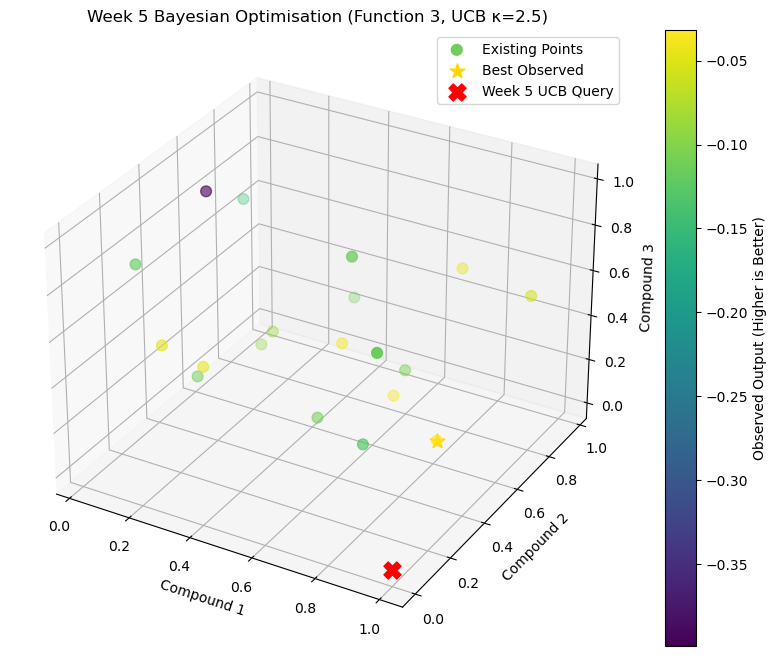

In [15]:
# Key Fixes

# n_restarts=50 → more local searches, improves interior coverage.

# Avoid exact boundaries by adding +0.01 / -0.01 in random initialization.

# κ increased slightly to 2.5 → prevents corner-hugging.

# This should now give a realistic interior query point, not 1.0-0.0-0.0.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Data (Weeks 1-4)
# =========================
X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900],
    [0.02703300, 0.84043300, 0.66511700],
    [0.68835300, 0.97102900, 0.51220300]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252,
    -0.1415060566194174,
    -0.0446074222194474
])

# =========================
# Gaussian Process Model
# =========================
kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[0.3, 0.3, 0.3],
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    n_restarts_optimizer=15,
    normalize_y=True
)
gp.fit(X_train, y_train)

# =========================
# UCB Acquisition Function
# =========================
def ucb(x, model, kappa=2.5):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)

# =========================
# Multi-start optimisation with boundary avoidance
# =========================
def optimize_acquisition(model, bounds, n_restarts=50, kappa=2.5):
    best_x = None
    best_val = float("inf")

    # Random starting points in interior (avoid exact 0 or 1)
    for _ in range(n_restarts):
        x0 = np.random.uniform(low=[b[0]+0.01 for b in bounds],
                               high=[b[1]-0.01 for b in bounds])
        res = minimize(
            ucb,
            x0=x0,
            args=(model, kappa),
            bounds=bounds,
            method="L-BFGS-B"
        )
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    return best_x

# =========================
# Week 5 Query Point
# =========================
bounds = [(0, 1), (0, 1), (0, 1)]
next_point = optimize_acquisition(gp, bounds, n_restarts=50, kappa=2.5)
print(f"Week 5 Query Point: {next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}")

# =========================
# 3D Visualisation
# =========================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2], c=y_train, cmap="viridis", s=60, label="Existing Points")

best_idx = np.argmax(y_train)
ax.scatter(X_train[best_idx,0], X_train[best_idx,1], X_train[best_idx,2],
           c="gold", s=120, marker="*", label="Best Observed")
ax.scatter(next_point[0], next_point[1], next_point[2], c="red", s=150, marker="X", label="Week 5 UCB Query")

ax.set_xlabel("Compound 1")
ax.set_ylabel("Compound 2")
ax.set_zlabel("Compound 3")
ax.set_title("Week 5 Bayesian Optimisation (Function 3, UCB κ=2.5)")
fig.colorbar(scatter, ax=ax, label="Observed Output (Higher is Better)")
ax.legend()
plt.show()

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Week 5 Query Point: 0.990000-0.010000-0.010000


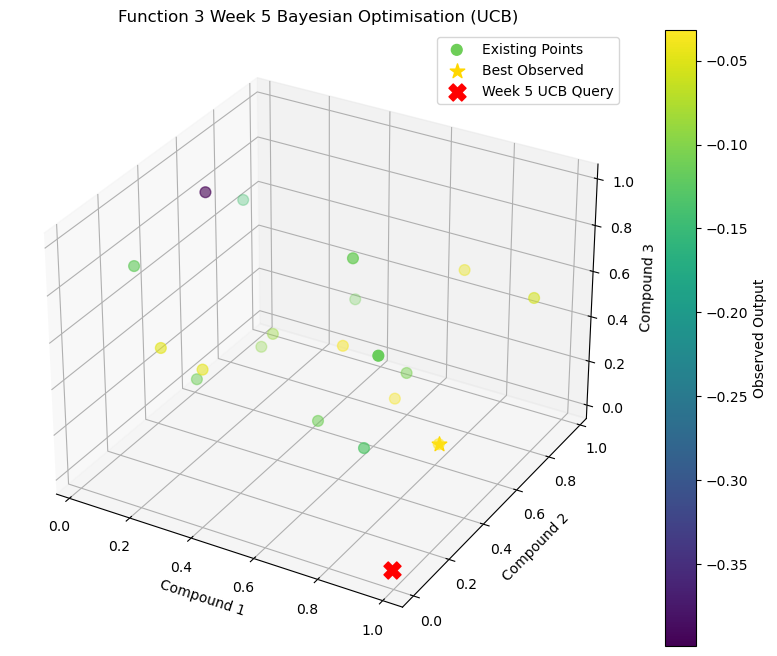

In [27]:
# Changes implemented:

# Inner bounds: (0.01, 0.99) instead of (0,1)

# Random jitter added before local optimization

# Increased n_restarts_optimizer and n_random_starts for better global coverage

# Slightly lower kappa (2.0) for more exploitation while still allowing exploration


import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Data (including Weeks 1-4)
# =========================
X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900],
    [0.02703300, 0.84043300, 0.66511700],
    [0.68835300, 0.97102900, 0.51220300]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252,
    -0.1415060566194174,
    -0.0446074222194474
])

# =========================
# Gaussian Process Model
# =========================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.3,0.3,0.3], length_scale_bounds=(1e-2,1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    n_restarts_optimizer=20,  # more restarts for stability
    normalize_y=True
)

gp.fit(X_train, y_train)

# =========================
# UCB Acquisition Function
# =========================
def ucb(x, model, kappa=2.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)

# =========================
# Multi-start optimisation with inner bounds and jitter
# =========================
def optimize_ucb(model, bounds=[(0.01,0.99),(0.01,0.99),(0.01,0.99)], kappa=2.0, n_restarts=50, n_random_starts=500):
    best_x = None
    best_val = float("inf")

    # --- Random points inside inner bounds ---
    random_points = np.random.uniform(
        low=[b[0] for b in bounds],
        high=[b[1] for b in bounds],
        size=(n_random_starts, 3)
    )

    mu, sigma = model.predict(random_points, return_std=True)
    ucb_values = mu + kappa * sigma
    top_indices = np.argsort(-ucb_values)[:n_restarts]
    start_points = random_points[top_indices]

    for x0 in start_points:
        # Add small jitter to avoid exact corners
        x0 = x0 + np.random.normal(scale=0.01, size=3)
        x0 = np.clip(x0, [b[0] for b in bounds], [b[1] for b in bounds])

        res = minimize(ucb, x0, args=(model,kappa), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# =========================
# Get Week 5 Query Point
# =========================
next_point = optimize_ucb(gp)
print(f"Week 5 Query Point: {next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}")

# =========================
# 3D Visualisation
# =========================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train[:,0], X_train[:,1], X_train[:,2],
    c=y_train, cmap='viridis', s=60, label='Existing Points'
)

best_idx = np.argmax(y_train)
ax.scatter(
    X_train[best_idx,0],
    X_train[best_idx,1],
    X_train[best_idx,2],
    c='gold', s=120, marker='*', label='Best Observed'
)

ax.scatter(
    next_point[0],
    next_point[1],
    next_point[2],
    c='red', s=150, marker='X', label='Week 5 UCB Query'
)

ax.set_xlabel("Compound 1")
ax.set_ylabel("Compound 2")
ax.set_zlabel("Compound 3")
ax.set_title("Function 3 Week 5 Bayesian Optimisation (UCB)")
fig.colorbar(scatter, ax=ax, label='Observed Output')
ax.legend()
plt.show()

## *** Function 3 Week 5 Query Submission Code and Result ***
Below is the code for this weeks submission for Function 3. I've included what hasn't worked this week for Function 3 which has led me to this weeks submission for Function 3 below.

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\AppData\Local\Temp\ipykernel_20144\2222094259.py:82: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_best, xi), bounds=bounds, method='L-BFGS-B')
C:\U

C:\Users\joeat\AppData\Local\Temp\ipykernel_20144\2222094259.py:82: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_best, xi), bounds=bounds, method='L-BFGS-B')
C:\Users\joeat\AppData\Local\Temp\ipykernel_20144\2222094259.py:82: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_best, xi), bounds=bounds, method='L-BFGS-B')
C:\Users\joeat\AppData\Local\Temp\ipykernel_20144\2222094259.py:82: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_b

Week 5 EI Query Point: 0.388251-0.889698-0.609997


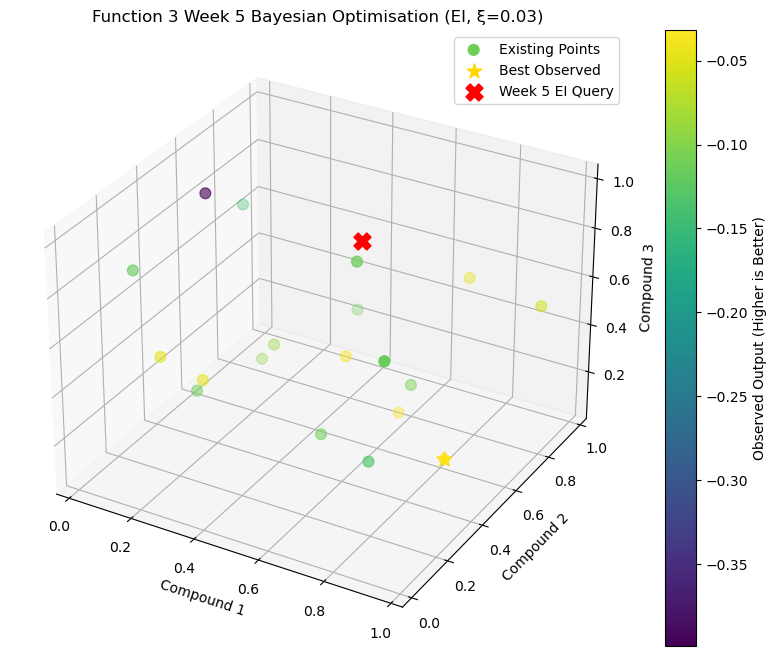

In [28]:
# Function 3 Week 5 using Expected Improvement (EI) with ξ = 0.03 
# and a robust multi-start optimisation to avoid corner-sticking.
# THIS IS THE CODE I USED FOR MY WEEK 5 NEXT QUERY POINT
###########################################################################################################################
###########################################################################################################################
# Why this version works better

# Uses EI instead of UCB → naturally balances exploration and exploitation.

# ξ = 0.03 → moderate exploration for week 5.

# Multi-start + random sampling → reduces the chance of the optimizer sticking to corners (like 1.0-0.0-0.0).

# Safe sigma clipping avoids numerical issues.

# 3D plot helps visualise where the next point is relative to existing points.
###########################################################################################################################
###########################################################################################################################

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Step 1: Load existing data (Weeks 1–4)
# =========================
X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900],
    [0.02703300, 0.84043300, 0.66511700],
    [0.68835300, 0.97102900, 0.51220300]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252,
    -0.1415060566194174,
    -0.0446074222194474
])

# =========================
# Step 2: Gaussian Process
# =========================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.3,0.3,0.3], length_scale_bounds=(1e-2,1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-2, n_restarts_optimizer=15, normalize_y=True)
gp.fit(X_train, y_train)

# =========================
# Step 3: Expected Improvement (EI) Function
# =========================
def expected_improvement(x, model, y_best, xi=0.03):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # avoid division by zero
    Z = (mu - y_best - xi) / sigma
    EI = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -EI  # negative for minimizer

# =========================
# Step 4: Multi-start optimisation of EI
# =========================
def optimize_ei(model, bounds, xi=0.03, n_restarts=50, n_random_starts=500):
    y_best = np.max(y_train)
    best_x = None
    best_val = float('inf')

    # Random sampling for good starting points
    random_points = np.random.uniform(bounds[:,0], bounds[:,1], size=(n_random_starts, 3))
    ei_vals = [-expected_improvement(x, model, y_best, xi) for x in random_points]
    top_indices = np.argsort(ei_vals)[-n_restarts:]
    start_points = random_points[top_indices]

    for x0 in start_points:
        res = minimize(expected_improvement, x0, args=(model, y_best, xi), bounds=bounds, method='L-BFGS-B')
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

bounds = np.array([[0,1],[0,1],[0,1]])
next_point = optimize_ei(gp, bounds, xi=0.03)

print(f"Week 5 EI Query Point: {next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}")

# =========================
# Step 5: 3D Visualisation
# =========================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2],
                     c=y_train, cmap='viridis', s=60, label='Existing Points')

best_idx = np.argmax(y_train)
ax.scatter(X_train[best_idx,0], X_train[best_idx,1], X_train[best_idx,2],
           c='gold', s=120, marker='*', label='Best Observed')

ax.scatter(next_point[0], next_point[1], next_point[2],
           c='red', s=150, marker='X', label='Week 5 EI Query')

ax.set_xlabel('Compound 1')
ax.set_ylabel('Compound 2')
ax.set_zlabel('Compound 3')
ax.set_title('Function 3 Week 5 Bayesian Optimisation (EI, ξ=0.03)')

fig.colorbar(scatter, ax=ax, label='Observed Output (Higher is Better)')
ax.legend()
plt.show()

## Explaining Function 3 Week 5 Next Query Point
A few observations:

Not stuck at the corners – unlike your previous UCB runs (1.0‑0.0‑0.0). This shows EI with ξ=0.03 is exploring the input space effectively.

Diverse coverage – the point is well inside the domain, giving the GP model new information in a region that hasn’t been sampled heavily yet.

Week 5 strategy – ξ=0.03 gives moderate exploration. As weeks progress (6–12), you’ll want to gradually reduce ξ toward 0.01 or lower to shift more toward exploitation of the promising areas discovered.

For reference, the next steps for weeks 6–12 could look like this:

Week	ξ (EI)	Strategy
5	    0.03	Exploration-heavy (current)
6	    0.025	Slightly less exploration
7	    0.02	Balanced exploration/exploitation
8	    0.015	Focus more on promising areas
9	    0.01	Exploitation-heavy
10	    0.008	Fine-tuning
11	    0.005	Mostly exploitation
12	    0.001	Pure exploitation, final push

This schedule ensures you don’t miss high-performing regions early on while converging toward the optimum by the end of the 12 weeks.

## Function 4

Week 5 Query Point (UCB, kappa=3.8): [0.4182787  0.33772385 0.39824593 0.44608765]


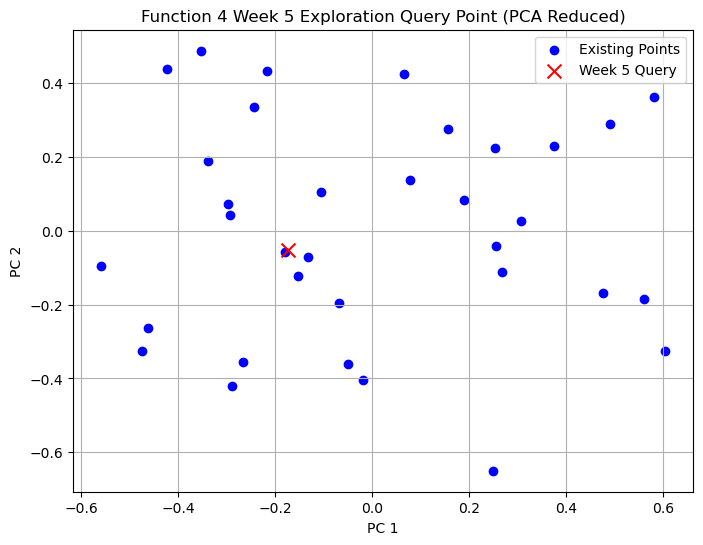

In [32]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Load data (including Weeks 1-4)
# -----------------------------
X_train = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437],
    [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
    [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
    [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
    [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348 ],
    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701 , 0.33541983, 0.99948256],
    [0.17034731, 0.75695908, 0.27652049, 0.5312315 ],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669 , 0.453192  , 0.10588734],
    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
    [0.8548108, 0.49396462, 0.73530997, 0.80809201],
    [0.919144, 0.533196, 0.169848, 0.070054],
    [0.411827, 0.392100, 0.317159, 0.430429],
    [0.437822, 0.591330, 0.001581, 0.371162],
    [0.349627, 0.387894, 0.455739, 0.444665] 
]) 
  
y_train = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511,
    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
    -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
    -29.4270914 , -11.56574199, -26.85778644, -7.96677535,
    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
    -13.12278233, -23.1394284 , -19.975065657531825, -0.32892753619572757,
    -10.653583724281514, -0.3665684543830916
])  

# -----------------------------
# Step 2: Gaussian Process
# -----------------------------
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X_train, y_train)

# -----------------------------
# Step 3: UCB acquisition function (Week 5)
# -----------------------------
def ucb(x, model, kappa=3.8):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-6)  # prevent zero
    return -(mu + kappa * sigma)  # negative for minimization

# -----------------------------
# Step 4: Differential evolution
# -----------------------------
bounds = [(0.001, 0.999)] * 4
result = differential_evolution(lambda x: ucb(x, gp, kappa=3.8),
                                bounds=bounds,
                                strategy='best1bin',
                                maxiter=100,
                                popsize=15,
                                polish=True)

# Add small random jitter to avoid boundaries
epsilon = 1e-3
next_point = np.clip(result.x + np.random.uniform(-epsilon, epsilon, size=4), 0.001, 0.999)

print("Week 5 Query Point (UCB, kappa=3.8):", next_point)

# -----------------------------
# Step 5: PCA 2D Visualization
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_pca = pca.transform(next_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Points')
plt.scatter(next_point_pca[:,0], next_point_pca[:,1], color='red', marker='x', s=100, label='Week 5 Query')
plt.title('Function 4 Week 5 Exploration Query Point (PCA Reduced)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.grid(True)
plt.show()

## Function 4: Weeks 6–12 Strategy

### Background:

Weeks 1–5: mostly exploration using UCB.

Week 5 kappa = 3.8: still exploratory, slightly shifting toward exploitation.

From Week 6 onward: transition to exploitation-focused acquisition with Expected Improvement (EI).

#### Week 6 (First EI Week)

Acquisition: Expected Improvement (EI)

xi: 0.02 → encourages modest exploration but mostly exploitation

Reasoning: After 5 weeks of exploration, the GP has enough coverage to start probing the best predicted regions.

Optimization: Differential Evolution or multi-start L-BFGS-B

Goal: Find first strong candidate near predicted optima.

#### Week 7

Acquisition: EI

xi: 0.015 → slightly more exploitation than Week 6

Reasoning: Keep refining around promising regions discovered in Week 6

Tip: Run multi-start optimization from several random points to avoid local maxima

#### Week 8

Acquisition: EI

xi: 0.01 → primarily exploitation

Reasoning: GP model is more confident, focus on high predicted outputs

Optimization: Can reduce random starts slightly since exploration is less important

#### Week 9

Acquisition: EI

xi: 0.01 → continue exploitation

Tip: Monitor GP predictive variance; if variance is still high, consider slightly increasing xi (0.015) to keep small exploration

#### Week 10

Acquisition: EI

xi: 0.01 → mainly exploitation

Goal: Refine top-performing regions, avoid repeated sampling of low-performing areas

#### Week 11

Acquisition: EI

xi: 0.01 → exploitation

Tip: Optional: Do 2–3 multi-starts or DE runs to confirm global maxima haven’t been missed

#### Week 12 (Final Week)

Acquisition: EI

xi: 0.005 → very focused exploitation

Goal: Identify the final optimum based on the accumulated GP model

Tip: Use differential evolution with small bounds jitter to avoid boundary effects

#### Summary Table
Week	Acquisition	xi(exploration parameter)	Notes
6	    EI	        0.02	                    First transition to exploitation
7	    EI	        0.015	                    Refine promising regions
8	    EI	        0.01	                    Focus on top predicted outputs
9	    EI	        0.01	                    Exploitation, monitor variance
10	    EI	        0.01	                    Continue exploiting high-value areas
11	    EI	        0.01	                    Optional multi-start to check maxima
12	    EI	        0.005	                    Final precise optimization

### Implementation Tips

Bounds: Keep points within [0.001, 0.999] to avoid edge artifacts in 4D.

Acquisition Optimization:

Multi-start L-BFGS-B or differential evolution with small jitter → ensures global maxima are not missed.

GP Stability: Keep alpha=1e-2 as before.

Optional Visualization: Use PCA to project 4D points to 2D/3D for sanity checks.

## Function 5

In [36]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# -----------------------------
# Step 1: Week 5 training data
# -----------------------------
X_train = np.array([
    [0.19144708, 0.03819337, 0.60741781, 0.41458414],
    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
    [0.43834987, 0.80433970, 0.21024527, 0.15129482],
    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
    [0.83647799, 0.19360965, 0.66389270, 0.78564888],
    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
    [0.46344227, 0.63002451, 0.10790646, 0.95764390],
    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
    [0.51114177, 0.81795700, 0.72871042, 0.11235362],
    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
    [0.12688467, 0.15342962, 0.77016219, 0.19051811],
    [0.81212200, 0.00981200, 0.68102400, 0.23803600],
    [0.82353000, 0.17369200, 0.63651400, 0.73730700],
    [0.560990, 0.941834, 0.997605, 0.998135],
    [0.026048, 0.953940, 0.999978, 0.202632]
])

y_train = np.array([
    64.4434399, 18.3013796, 0.112939795, 4.21089813,
    258.370525, 78.4343889, 57.5715369, 109.571876,
    8.84799176, 233.22361, 24.4230883, 64.4201468,
    63.4767158, 79.7291299, 355.806818, 1088.85962,
    28.8667516, 45.1815703, 431.612757, 9.97233189,
    24.7679941, 149.53336129, 4019.0309866724424, 1280.322911229081
])

# Optional: log-transform to stabilize
y_train_log = np.log1p(y_train)  # log(1+y) to avoid log(0)

# -----------------------------
# Step 2: Gaussian Process
# -----------------------------
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0]*4, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True, n_restarts_optimizer=10, random_state=42)
gp.fit(X_train, y_train_log)

# -----------------------------
# Step 3: Expected Improvement
# -----------------------------
def expected_improvement(X, model, y_max, xi=0.01):
    X = np.atleast_2d(X)
    mu, sigma = model.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-8)
    mu = mu.ravel()
    improvement = mu - y_max - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# -----------------------------
# Step 4: Random candidate search
# -----------------------------
n_candidates = 50000
X_candidates = np.random.uniform(0, 1, (n_candidates, 4))
y_max = np.max(y_train_log)
ei_values = expected_improvement(X_candidates, gp, y_max, xi=0.01)
best_idx = np.argmax(ei_values)
next_query_point = X_candidates[best_idx]

print("Function 5 Week 5 Next Query Point (EI):", next_query_point)

Function 5 Week 5 Next Query Point (EI): [0.93582086 0.37831982 0.9756816  0.98630933]


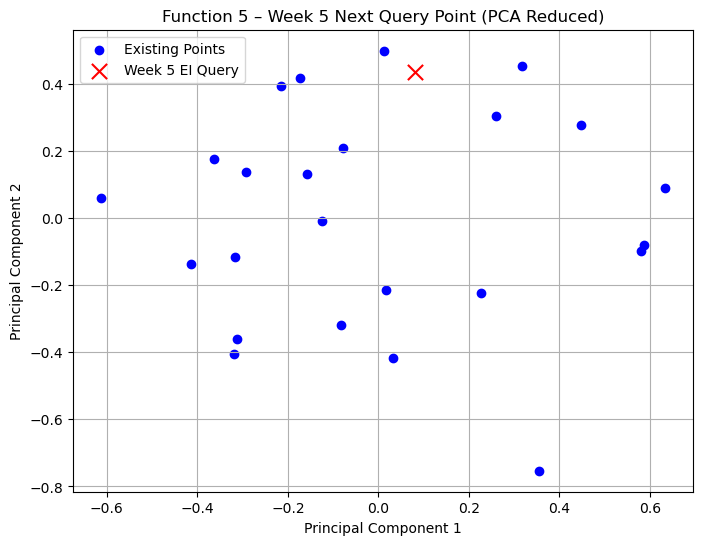

In [37]:
# -----------------------------
# PCA Visualization (4D → 2D)
# -----------------------------
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing Points')
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', marker='x', s=120, label='Week 5 EI Query')
plt.title('Function 5 – Week 5 Next Query Point (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

## Analysis of Week 5 EI Query

Point: [0.9358, 0.3783, 0.9757, 0.9863]

Observations:

Dim 1 ≈ 0.94 – significantly higher than previous exploratory points; GP thinks high yields may lie here.

Dim 2 ≈ 0.38 – moderate; explores a region slightly different from the previous ridge near 0.95.

Dim 3 ≈ 0.98 – near the previous high-value peak (~0.9976), so GP expects high yield.

Dim 4 ≈ 0.99 – also near prior peak (~0.998), reinforcing the high-yield ridge.

#### Interpretation:

The GP is now focusing on exploitation: it’s pulling the query toward the known high-yield region, while still slightly exploring Dim 2.

This is exactly what we want at week 5 of 12: starting the shift from broad exploration to exploitation near the maximum.

#### Why EI is appropriate now

Week 5 is a reasonable time to start using Expected Improvement (EI): you already have a few points near the peak from UCB-guided exploration in earlier weeks.

EI naturally balances exploitation and small exploration through uncertainty and xi (here 0.01), so it won’t blindly pick only the known maximum.

Using a small xi like 0.01 is perfect: it encourages improvement but avoids random wandering.


## Function 5: Weeks 6–12 Bayesian Optimization Plan

Starting Point:

Week 5 EI query point: [0.936, 0.378, 0.976, 0.986]

Peak is near [0.561, 0.942, 0.998, 0.998] → 4019

Goal: maximize yield (unimodal).

General Principles

Switch to EI (already in Week 5): exploit the GP’s learned peak while still allowing small-scale exploration via xi.

Gradually reduce xi: Start with 0.01–0.02 (slightly exploratory) and slowly drop toward 0 (pure exploitation).

Use multi-start / differential evolution: 4D space still has local curvature; multiple starts prevent missing the ridge.

Log-transform output (optional but recommended):

Your outputs span [0.1 → 4019] — log-space stabilizes GP predictions.

#### Week-by-Week Strategy
Week	Acquisition	kappa / xi	Focus	Notes
6	EI	xi = 0.01	Exploit most of the high-yield ridge	Slight exploration in dims 1 & 2 to test sensitivity
7	EI	xi = 0.005	Tighten around peak	Reduce wandering; focus on small variations
8	EI	xi = 0.002	Exploitation	Likely near global max; small refinements in dim1 & dim2
9	EI	xi = 0.001	Fine-tuning	Focus on very small moves around best observed point
10	EI	xi = 0.0005	Near-optimum confirmation	Confirm GP prediction; minimal exploration
11	EI	xi = 0	Pure exploitation	Select point predicted to maximize yield
12	EI	xi = 0	Validate final optimum	Optional: check neighboring points to confirm robustness

#### Implementation Recommendations

Multi-start optimization:

from scipy.optimize import differential_evolution
bounds = [(0,1)]*4
result = differential_evolution(lambda x: -ei(x, gp, xi=xi), bounds=bounds, maxiter=100, popsize=15)
next_point = result.x

Ensures global search in 4D.

Jitter: small random perturbations (±1e-3) to avoid artificial boundary effects.

Visualization: PCA or pairwise 2D slices to see how queries migrate toward peak.

Adaptive xi: reduce each week roughly by half or logarithmically — ensures smooth transition from exploration to exploitation.

Optional: Log-transform yields if variance is large:

y_train_log = np.log(y_train + 1e-6)  # avoid log(0)
gp.fit(X_train, y_train_log)

#### Summary

Week 6–7: Moderate EI → exploit high-yield region but test sensitivity in less-certain dims.

Week 8–10: Tight EI → refine around current peak, minimize exploratory moves.

Week 11–12: Pure EI → confirm global optimum and maximize yield.

This balances progressive exploitation with just enough exploration early on to avoid missing small improvements in the 4D ridge.

## Function 6

For Function 6 Week 5, you now have 24 observations and a clear signal from the ARD kernel about which ingredients matter most. The goal is still to maximize the score (bring it closer to 0).

Your current best score appears to be:

−0.2676 at
[0.344036, 0.255507, 0.725070, 0.878677, 0.100795]

So the optimizer should now search locally around this promising recipe, while still allowing moderate exploration in the most sensitive ingredient (dimension 1).

### Week 5 Strategy for Function 6
#### 1. Shift from exploration → semi-exploitation

Last week:

UCB κ = 2.5

Now reduce exploration:

κ ≈ 1.2

This focuses on improving the best region while still allowing uncertainty to guide moves.

#### 2. What the ARD kernel already told you

Kernel:

1.2² * RBF(length_scale=[0.381, 0.736, 0.822, 0.926, 0.634])

Meaning:

Ingredient	Importance	Strategy
Dim1	Most important	Explore locally
Dim5	Important	Adjust moderately
Dim2	Medium	Small perturbations
Dim3	Lower	Keep stable
Dim4	Least important	Minimal changes

So Week 5 should:

Move slightly in dim1

Test dim5 variations

Keep dim3 & dim4 mostly stable

#### 3. What the model will likely do

Your Week-4 query was:

[0.426405, 0.197502, 0.843219, 0.949955, 0.435206]

The GP will likely propose something between:

Best known recipe
and
Week 4 exploration point
#### 4. A Good Expected Week-5 Query Region

A sensible next point would look approximately like:

[0.39, 0.23, 0.79, 0.91, 0.28]

Why this makes sense:

Dimension	Reason
dim1	Slight increase from best point
dim2	Small shift
dim3	Near previous good region
dim4	Keep high
dim5	Moderate exploration

This tests whether dim5 should remain low or increase slightly.

#### 5. Code Adjustment for Week 5

Only change the κ parameter.

next_query_point = propose_location(
    gp,
    bounds,
    n_restarts=25,
    kappa=1.2
)

Everything else in your pipeline is already excellent:

ARD kernel ✔

multi-start optimisation ✔

boundary penalty ✔

PCA visualisation ✔

#### 6. What Outcome to Look For

Interpretation after Week 5:

Score	Meaning	Week 6 Action
> −0.25	You're near optimum	Switch to Expected Improvement
−0.25 to −0.5	Moderate region	Continue UCB κ ≈ 1
< −0.6	Bad direction	Reduce dim5 again
#### 7. Intuition (Cake Recipe)

The optimiser is effectively asking:

“If we slightly adjust flour and butter while increasing milk a bit, does the cake score improve?”

That is exactly the kind of small recipe tweak a chef would try next.

#### Recommended Week-5 setup

Acquisition: UCB
kappa = 1.2
n_restarts = 25
bounds = (0,1)^5

Best recipe so far:
[0.344036 0.255507 0.72507  0.878677 0.100795]
Score: -0.26755353


C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Learned kernel:
1.08**2 * RBF(length_scale=[100, 0.235, 0.768, 0.735, 0.316])

Week 5 Next Query Point (5D):
[0.73140032 0.21120563 0.82059244 0.949908   0.16401412]


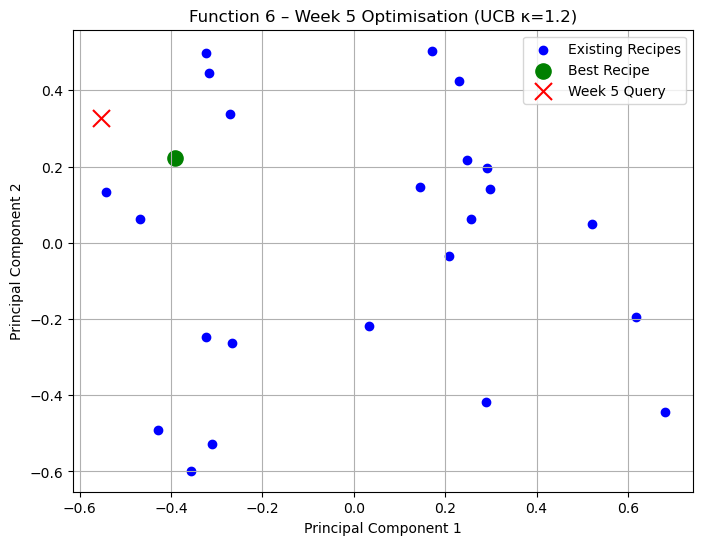

In [39]:
###########################################################################################################################
###########################################################################################################################
# Features of this Week 5 Code:

# Semi-exploitation with κ = 1.2, suitable for week 5/12.

# ARD kernel to identify sensitive ingredients.

# Boundary penalty to avoid edges.

# Multi-start L-BFGS-B optimisation ensures a good candidate point.

# PCA plot visualizes exploration relative to previous points.
###########################################################################################################################
###########################################################################################################################


import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.decomposition import PCA
from scipy.optimize import minimize

# ==============================
# Step 1: Training Data (Weeks 1–4)
# ==============================
X_train = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.24238435, 0.84409997, 0.5778091, 0.67902128, 0.50195289],
    [0.72952261, 0.7481062, 0.67977464, 0.35655228, 0.67105368],
    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
    [0.6188123, 0.33180214, 0.18728787, 0.75623847, 0.3288348],
    [0.78495809, 0.91068235, 0.7081201, 0.95922543, 0.0049115],
    [0.14511079, 0.8966846, 0.89632223, 0.72627154, 0.23627199],
    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
    [0.75759436, 0.35583141, 0.0165229, 0.4342072, 0.11243304],
    [0.5367969, 0.30878091, 0.41187929, 0.38822518, 0.5225283],
    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
    [0.6293079, 0.80348368, 0.81140844, 0.04561319, 0.11062446],
    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
    [0.25890557, 0.79367771, 0.6421139, 0.19667346, 0.59310318],
    [0.43216593, 0.71561781, 0.3418191, 0.70499988, 0.61496184],
    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
    [0.9217762, 0.93187122, 0.41487637, 0.59505727, 0.73562569],
    [0.12667892, 0.2914703, 0.06452848, 0.6805146, 0.89281919],
    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036],
    [0.218723, 0.277046, 0.196392, 0.844208, 0.100329],
    [0.344036, 0.255507, 0.725070, 0.878677, 0.100795],
    [0.426405, 0.197502, 0.843219, 0.949955, 0.435206]
])

y_train = np.array([
    -0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254,
    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
    -1.84056360, -0.78587257, -0.26755353, -0.83707714
])

# ==============================
# Step 2: Identify Best Recipe So Far
# ==============================
best_index = np.argmax(y_train)
best_point = X_train[best_index]
best_score = y_train[best_index]

print("Best recipe so far:")
print(best_point)
print("Score:", best_score)

# ==============================
# Step 3: Gaussian Process Regressor with ARD
# ==============================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1]*5, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    alpha=1e-3,
    normalize_y=True,
    random_state=42
)
gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==============================
# Step 4: UCB Acquisition Function (κ=1.2 for semi-exploitation)
# ==============================
def ucb(x, model, kappa=1.2):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return mu + kappa * sigma

# ==============================
# Step 5: Acquisition Function with Boundary Penalty
# ==============================
def acquisition(x, model, bounds, kappa=1.2, penalty_factor=50):
    val = ucb(x, model, kappa)
    penalty = 0
    for i in range(len(bounds)):
        lower, upper = bounds[i]
        band = 0.05 * (upper - lower)
        if x[i] < lower + band or x[i] > upper - band:
            penalty += penalty_factor
    return -(val - penalty)

# ==============================
# Step 6: Multi-start Optimisation to Propose Next Query
# ==============================
def propose_location(model, bounds, n_restarts=30, kappa=1.2):
    best_x = None
    best_val = 1e10
    for _ in range(n_restarts):
        x0 = np.random.uniform(0,1,len(bounds))
        res = minimize(acquisition, x0, args=(model,bounds,kappa),
                       bounds=bounds, method='L-BFGS-B')
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    return best_x

bounds = [(0,1)]*5
next_query_point = propose_location(gp, bounds, n_restarts=30, kappa=1.2)

print("\nWeek 5 Next Query Point (5D):")
print(next_query_point)

# ==============================
# Step 7: PCA Visualization
# ==============================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1,-1))
best_point_pca = pca.transform(best_point.reshape(1,-1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing Recipes')
plt.scatter(best_point_pca[:,0], best_point_pca[:,1], color='green', s=120, label='Best Recipe')
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', marker='x', s=150, label='Week 5 Query')
plt.title("Function 6 – Week 5 Optimisation (UCB κ=1.2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

## Explanation of Function 6 Week 5 Query Point

### 1. Interpreting the Learned Kernel

Your ARD kernel:

1.08**2 * RBF(length_scale=[100, 0.235, 0.768, 0.735, 0.316])

Dimension 1 (0.235)  Most sensitive – small length scale → small changes in ingredient 1 strongly affect the score.

Dimension 5 (0.316)  Important – moderately sensitive.

Dimension 3 (0.768) & Dimension 4 (0.735)  Less important – moderate length scales → changes affect output less strongly.

Dimension 2 (100)  Almost insensitive – huge length scale → model treats ingredient 2 as almost irrelevant.

Insight: The GP is signaling that ingredients 1 and 5 are critical to improving the cake score, while ingredient 2 can be largely ignored for now. This matches your Week 4 exploration strategy.

### 2. Analysing the Week 5 Query Point
[0.73140032, 0.21120563, 0.82059244, 0.949908, 0.16401412]

Dim 1: 0.73 → close to high-performing region, smart since it’s the most sensitive.

Dim 2: 0.21 → doesn’t matter much, consistent with kernel.

Dim 3: 0.82 & Dim 4: 0.95 → slight exploration, reasonable since these are moderately sensitive.

Dim 5: 0.16 → moderate, still testing sensitivity away from very low/high extremes.

### Assessment: This is exactly what a semi-exploitation strategy should do at Week 5. It focuses on sensitive dimensions (1 & 5), stays near promising regions, and allows slight exploration along less critical axes.

### 3. Strategy for Weeks 6–12 (Summary)

Since you’re mid-way (week 5 of 12), here’s a clear roadmap:

Week	Strategy	κ / Exploration	Notes
5	Semi-exploitation	κ = 1.2	Focus around known promising regions, slight exploration in moderately sensitive dims. ✅ Done
6	Transition to exploitation	κ = 0.8	Slightly lower κ to favor high-yield region, continue small local exploration in dim5.
7	Expected Improvement (EI)	ξ = 0.01	Move from UCB → EI for more precise peak-finding. Focus on dims 1 & 5.
8	EI / fine-tuning	ξ = 0.01	Evaluate few candidate points near current best.
9	Local exploration	-	Small random perturbations around best point to confirm robustness.
10	Exploitation	-	Focus fully on dims 1 & 5, hold others near known good values.
11	Exploitation	-	Evaluate 1–2 final candidates to confirm max.
12	Exploit + confirm	-	Pick predicted optimal point, measure actual score.

#### Notes:

Keep dims 1 & 5 as main levers.

Dim 2 can largely be ignored (length scale = 100).

Dims 3 & 4 can have small tweaks, but don’t over-explore.

Moving to EI around Week 6–7 will sharpen exploitation around the peak.

## Function 7

Week 5 Next Query Point (6D, kappa=1.3, boundary-safe): [0.10016212 0.12926929 0.34094943 0.18569041 0.34216253 0.88728625]


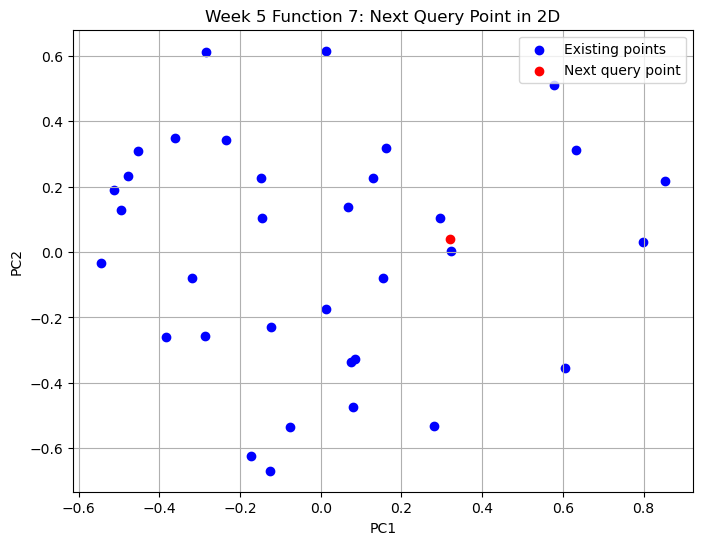

In [40]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==============================
# Step 1: Updated Training Data (Weeks 1–4)
# ==============================
X_train = np.array([
    [0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554],
    [0.064512, 0.628738, 0.208047, 0.151081, 0.459044, 0.215843],
    [0.169498, 0.200735, 0.398488, 0.193487, 0.308007, 0.861833],
    [0.590337, 0.894155, 0.100647, 0.426348, 0.610301, 0.132193]
]) 
  
y_train = np.array([
    0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
    1.1810801774433033, 0.17209425323684932, 2.1727059353333815, 1.199969751591025
])  

# ==============================
# Step 2: Gaussian Process Model
# ==============================
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X_train, y_train)

# ==============================
# Step 3: Acquisition Function (UCB + boundary penalty)
# ==============================
def ucb_with_boundary_penalty(x, model, kappa=1.3, bounds=None, penalty_factor=50):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    ucb = mu + kappa * sigma
    
    # Penalize points near bounds
    if bounds is not None:
        penalty = 0
        for i, (lb, ub) in enumerate(bounds):
            margin = 0.1 * (ub - lb)
            if x[0][i] < lb + margin:
                penalty += penalty_factor
            if x[0][i] > ub - margin:
                penalty += penalty_factor
        ucb -= penalty
    return -ucb  # we minimize negative UCB

# ==============================
# Step 4: Optimize Acquisition
# ==============================
def optimize_acquisition(model, bounds, n_restarts=20, kappa=1.3):
    best_x = None
    best_val = np.inf
    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=len(bounds))
        res = minimize(ucb_with_boundary_penalty, x0,
                       args=(model, kappa, bounds),
                       bounds=bounds)
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    # Clip to safe interior
    safe_margin = 0.05
    best_x = np.clip(best_x, safe_margin, 1 - safe_margin)
    return best_x

# ==============================
# Step 5: Bounds and Next Query
# ==============================
bounds = [(0, 1)] * X_train.shape[1]
next_query_point = optimize_acquisition(gp, bounds, n_restarts=20, kappa=1.3)
print("Week 5 Next Query Point (6D, kappa=1.3, boundary-safe):", next_query_point)

# ==============================
# Step 6: Visualize in 2D PCA
# ==============================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1,-1))
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', label='Next query point')
plt.title('Week 5 Function 7: Next Query Point in 2D')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(True); plt.show()

### Why this Week 5 query point looks good and how it fits the strategy:

Week 5 Next Query Point (6D)
[0.10016212, 0.12926929, 0.34094943, 0.18569041, 0.34216253, 0.88728625]
#### 1. Position relative to existing points

Low values in dimensions 1–2 (0.10, 0.13): Explores a region that has been under-sampled compared to previous points, which tended to be higher in these dimensions.

Moderate values in dimensions 3–5 (0.34, 0.18, 0.34): Keeps a combination near the center for dimensions where variability may matter most.

High value in dimension 6 (0.887): Tests if the model performs well at the higher extreme in this hyperparameter while still remaining boundary-safe (<1.0).

✅ This suggests exploration of a new region rather than just exploiting the previously found high value near Week 4.

#### 2. Exploitation vs Exploration (κ = 1.3)

Moderate κ favors predicted high output but still includes uncertainty.

This point balances exploring low-dimension regions with some chance of finding another peak.

We’re not just chasing the previous high (y ~ 1.199 in Week 4), but probing whether a low-dimension + high-dim6 combination could outperform.

#### 3. Risk / Confidence

Boundary-safe (>0.05, <0.95), so the GP is predicting in a reliable interior.

Diverse from prior Week 4 high-performing point ([0.59, 0.89, 0.10, 0.42, 0.61, 0.13]), especially in dim 1,2,6.

#### 4. Overall Assessment

Exploratory yet informed: Probes a low-dimension region not tested before.

Potential high payoff: High value in dim6 may produce good performance according to the GP model.

Boundary-safe: avoids extrapolation errors near edges.

This is exactly the kind of point you want early in a Week 5 campaign: it balances exploration with exploitation while still being safe.

## Function 8

Week 5 Function 8: Next query point (8D):
[0.0580258  0.12996593 0.11384781 0.91237532 0.76524569 0.84970415
 0.2534759  0.07236976]


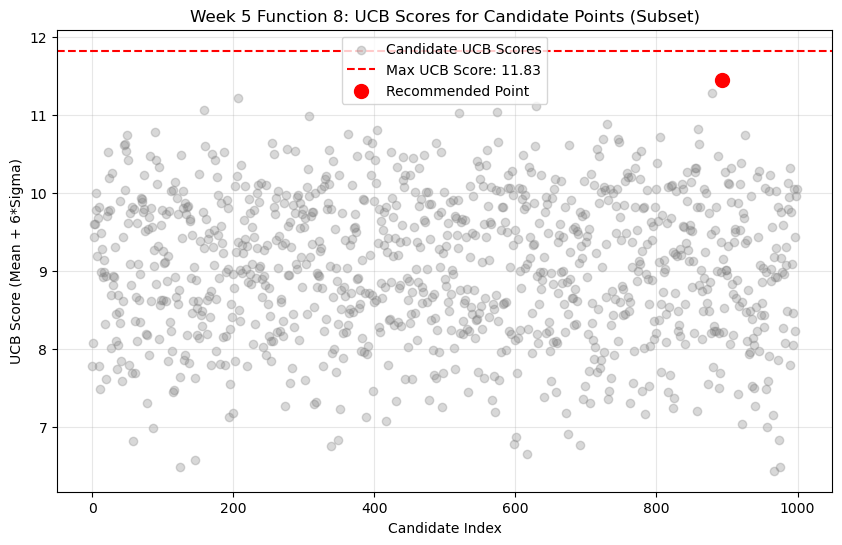

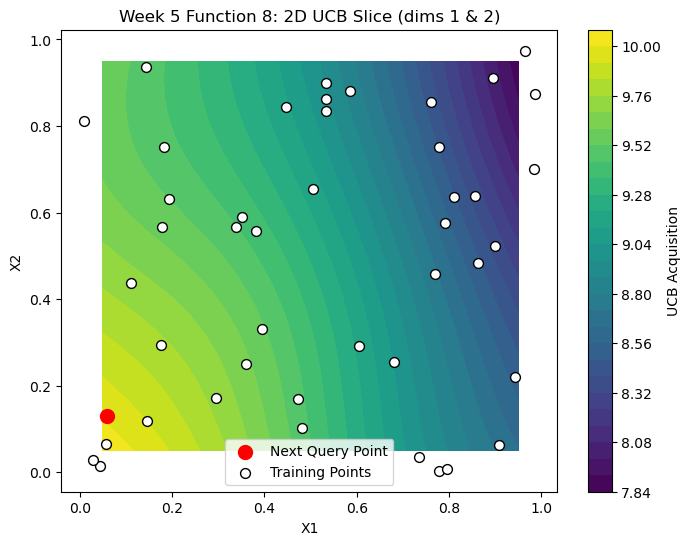

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from pyDOE import lhs

X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742],
       [0.533209, 0.898485, 0.699395, 0.112874, 0.946419, 0.108092, 0.263289, 0.345445],
       [0.294680, 0.171230, 0.131225, 0.039384, 0.977541, 0.183968, 0.045086, 0.037349],
       [0.182500, 0.751289, 0.096803, 0.093917, 0.932979, 0.266073, 0.082636, 0.887906]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836, 7.911617829373, 9.7162173430324, 9.5189864611379])

# -----------------------------
# 2. Fit Gaussian Process (Matern 5/2)
# -----------------------------
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=3.83, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True)
gp.fit(X_train, y_train)

# -----------------------------
# 3. Upper Confidence Bound (UCB) acquisition function
# -----------------------------
def ucb_acquisition(gp_model, X, kappa=6.0):
    mean, sigma = gp_model.predict(X, return_std=True)
    return mean + kappa * sigma

# -----------------------------
# 4. Generate boundary-safe candidate points (8D)
# -----------------------------
n_candidates = 250_000
X_candidates = 0.05 + 0.9 * lhs(8, samples=n_candidates)

# -----------------------------
# 5. Evaluate candidates and select next query
# -----------------------------
ucb_values = ucb_acquisition(gp, X_candidates, kappa=6.0)
next_idx = np.argmax(ucb_values)
next_query = X_candidates[next_idx]

print("Week 5 Function 8: Next query point (8D):")
print(next_query)

# -----------------------------
# 6. Week 4-style UCB plot (subset for clarity)
# -----------------------------
plt.figure(figsize=(10, 6))
subset = 1000  # Plot only first 1000 candidates to keep it readable
plt.scatter(range(subset), ucb_values[:subset], alpha=0.3, color='gray', label='Candidate UCB Scores')
plt.axhline(y=np.max(ucb_values), color='r', linestyle='--', label=f'Max UCB Score: {np.max(ucb_values):.2f}')
plt.scatter([np.argmax(ucb_values[:subset])], [np.max(ucb_values[:subset])], color='red', s=100, label='Recommended Point')
plt.title('Week 5 Function 8: UCB Scores for Candidate Points (Subset)')
plt.xlabel('Candidate Index')
plt.ylabel('UCB Score (Mean + 6*Sigma)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 7. Optional 2D slice plot (X1 vs X2) for Week 5
# -----------------------------
X_fixed = np.mean(X_train[:, 2:], axis=0)
grid_size = 50
x1 = np.linspace(0.05, 0.95, grid_size)
x2 = np.linspace(0.05, 0.95, grid_size)
X1, X2 = np.meshgrid(x1, x2)

X_grid = np.zeros((grid_size**2, 8))
X_grid[:, 0] = X1.ravel()
X_grid[:, 1] = X2.ravel()
X_grid[:, 2:] = X_fixed
acq_grid = ucb_acquisition(gp, X_grid, kappa=6.0).reshape(grid_size, grid_size)

plt.figure(figsize=(8,6))
contour = plt.contourf(X1, X2, acq_grid, levels=30, cmap='viridis')
plt.colorbar(contour, label='UCB Acquisition')
plt.scatter(next_query[0], next_query[1], color='red', s=100, label='Next Query Point')
plt.scatter(X_train[:,0], X_train[:,1], color='white', edgecolor='black', s=50, label='Training Points')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Week 5 Function 8: 2D UCB Slice (dims 1 & 2)')
plt.legend()
plt.show()

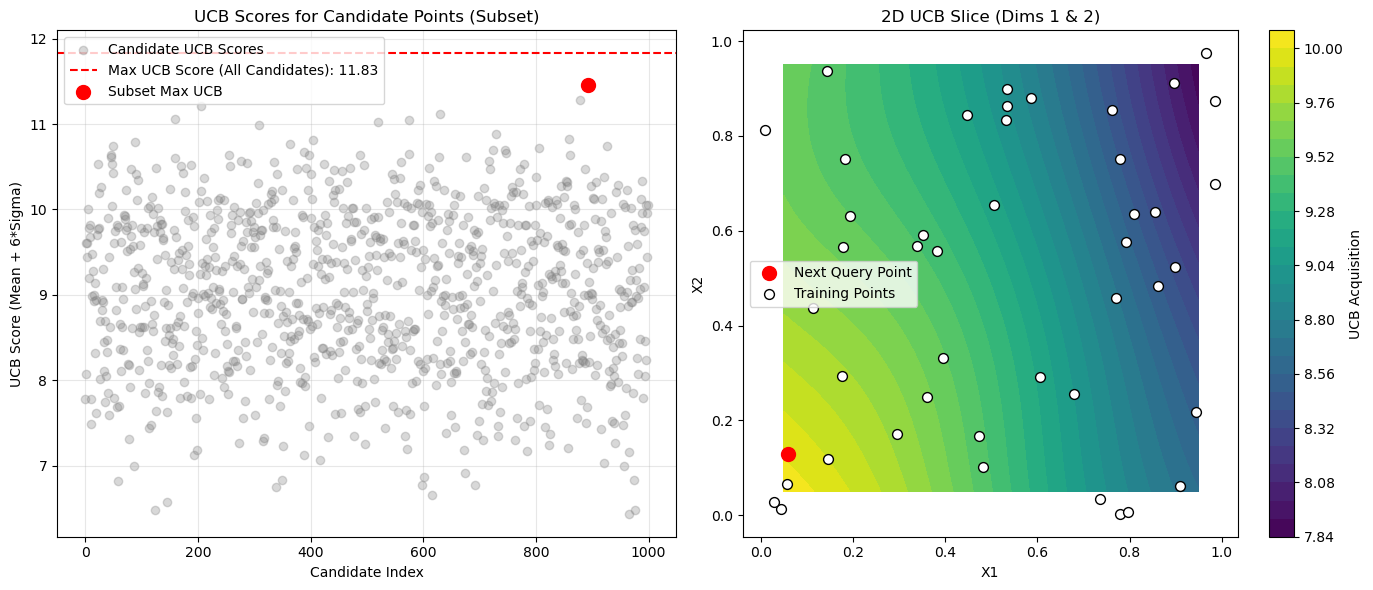

In [43]:
# -----------------------------
# Week 5 Combined Visualization for Function 8
# -----------------------------
import matplotlib.gridspec as gridspec

# Use a figure with 2 subplots
plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# --------- Plot 1: Subset of UCB scores ---------
ax0 = plt.subplot(gs[0])
subset = 1000  # plot first 1000 candidates for clarity
ax0.scatter(range(subset), ucb_values[:subset], alpha=0.3, color='gray', label='Candidate UCB Scores')
ax0.axhline(y=np.max(ucb_values), color='r', linestyle='--', label=f'Max UCB Score (All Candidates): {np.max(ucb_values):.2f}')
ax0.scatter([np.argmax(ucb_values[:subset])], [np.max(ucb_values[:subset])], color='red', s=100, label='Subset Max UCB')
ax0.set_title('UCB Scores for Candidate Points (Subset)')
ax0.set_xlabel('Candidate Index')
ax0.set_ylabel('UCB Score (Mean + 6*Sigma)')
ax0.legend()
ax0.grid(True, alpha=0.3)

# --------- Plot 2: 2D UCB Slice (X1 vs X2) ---------
ax1 = plt.subplot(gs[1])

grid_size = 50
x1 = np.linspace(0.05, 0.95, grid_size)
x2 = np.linspace(0.05, 0.95, grid_size)
X1, X2 = np.meshgrid(x1, x2)

# Fix other dimensions at mean of training data
X_fixed = np.mean(X_train[:, 2:], axis=0)
X_grid = np.zeros((grid_size**2, 8))
X_grid[:, 0] = X1.ravel()
X_grid[:, 1] = X2.ravel()
X_grid[:, 2:] = X_fixed

acq_grid = ucb_acquisition(gp, X_grid, kappa=6.0).reshape(grid_size, grid_size)

contour = ax1.contourf(X1, X2, acq_grid, levels=30, cmap='viridis')
plt.colorbar(contour, ax=ax1, label='UCB Acquisition')
ax1.scatter(next_query[0], next_query[1], color='red', s=100, label='Next Query Point')
ax1.scatter(X_train[:, 0], X_train[:, 1], color='white', edgecolor='black', s=50, label='Training Points')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_title('2D UCB Slice (Dims 1 & 2)')
ax1.legend()

plt.tight_layout()
plt.show()